# Red wine classification tutorial

In [1]:
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn import neighbors
from sklearn import tree
from sklearn import linear_model 
from sklearn import metrics
from sklearn import preprocessing
from sklearn import model_selection 
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

The dataset is from: https://archive.ics.uci.edu/ml/datasets/wine+quality

From the documentation: "The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine.
   For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009] (https://doi.org/10.1016/j.dss.2009.05.016).
   Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables 
   are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.)."
   
Input variables (based on physicochemical tests):  
   1 - fixed acidity  
   2 - volatile acidity  
   3 - citric acid  
   4 - residual sugar  
   5 - chlorides  
   6 - free sulfur dioxide  
   7 - total sulfur dioxide  
   8 - density  
   9 - pH  
   10 - sulphates  
   11 - alcohol  
   Output variable (based on sensory data):   
   12 - quality (score between 0 and 10)  

Missing Attribute Values: None

This analysis was inspired by analyses by Nataliia Rastoropova (https://medium.com/analytics-vidhya/step-by-step-guide-for-predicting-wine-quality-using-scikit-learn-de5869f8f91a) and Garry Malloy (https://rpubs.com/garrym3k/175762).

## Load and preprocess the data

In [2]:
# Load in the red wine data from the UCI ML website.
df = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',sep=';')

# Take a look
print(df.head(10))

# Data dimensionality (rows, colums)
print(df.shape)

# Data information
df.info()

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   
5            7.4              0.66         0.00             1.8      0.075   
6            7.9              0.60         0.06             1.6      0.069   
7            7.3              0.65         0.00             1.2      0.065   
8            7.8              0.58         0.02             2.0      0.073   
9            7.5              0.50         0.36             6.1      0.071   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0

In [3]:
# Now separate the dataset as response variable and feature variables
X = df.drop('quality', axis=1)
y = df['quality']

# Train and Test splitting of data
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=25)
print(X_train)

# Applying Standard scaling (zero mean and unit variance)
# Scaling values determined using only the training set, but applied to both training and test sets
# Output is numpy.ndarray
sc = preprocessing.StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)
print(X_train)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
223             8.6             0.645         0.25            2.00      0.083   
1510            6.4             0.360         0.21            2.20      0.047   
280            11.4             0.260         0.44            3.60      0.071   
810             7.3             0.490         0.10            2.60      0.068   
166             6.8             0.640         0.10            2.10      0.085   
...             ...               ...          ...             ...        ...   
1341            7.5             0.510         0.02            1.70      0.084   
143             6.3             0.390         0.08            1.70      0.066   
474            10.5             0.280         0.51            1.70      0.080   
318             9.8             0.660         0.39            3.20      0.083   
1156            8.5             0.180         0.51            1.75      0.071   

      free sulfur dioxide  

## Explore the data

3 8


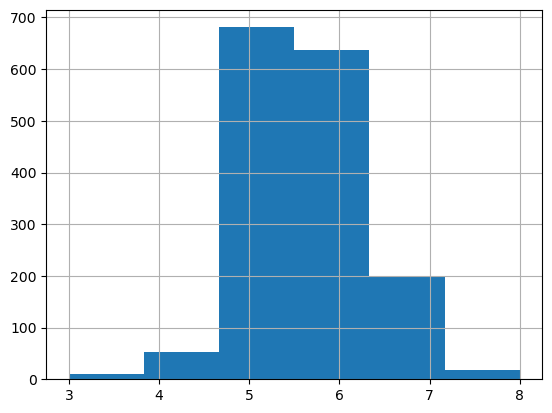

In [10]:
# Histogram of the class distribution
print (min(y),max(y))
y.hist(bins=6); # non-uniform distribution into classes

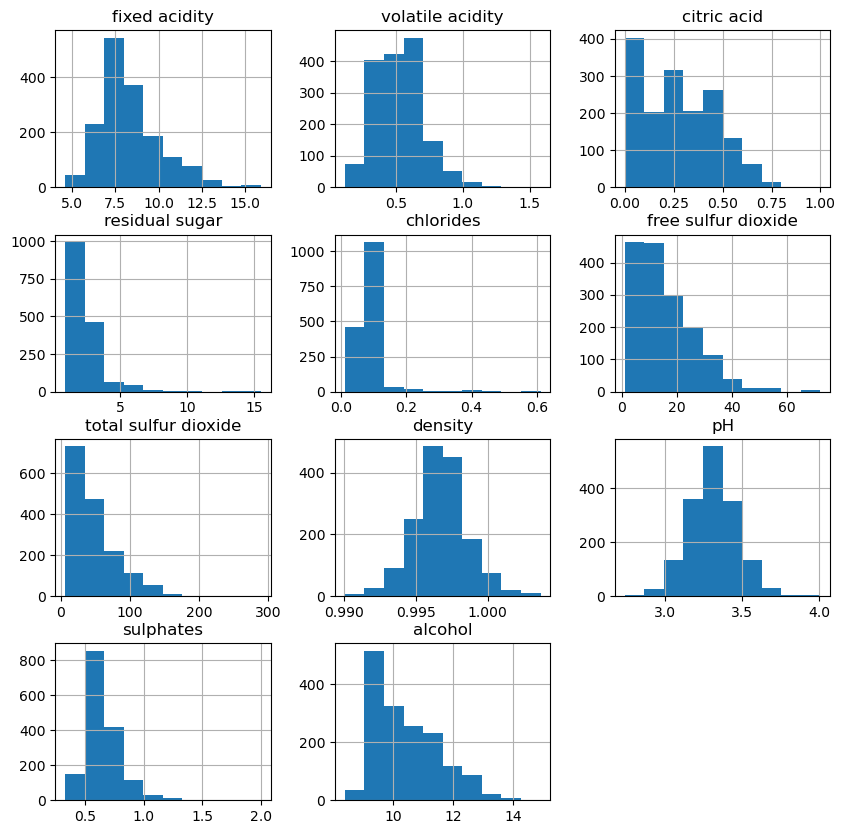

In [12]:
# Histogram of the feature distributions
X.hist(bins=10,figsize=(10,10)); # last ; supresses the return of the array description
#plt.show()

In [13]:
# Print the correlation coefficient of each feature with the class
corr_matrix = df.corr()
print(corr_matrix["quality"].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


AttributeError: QuadMesh.set() got an unexpected keyword argument 'title'

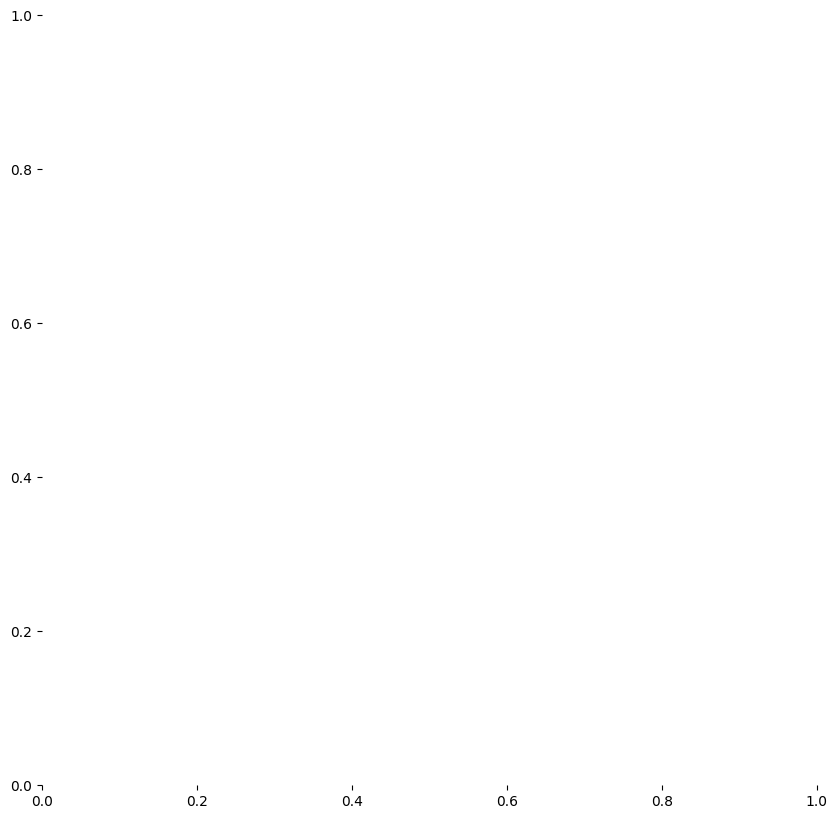

In [6]:
from src.utils import correlation_matrix
colum_names = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

correlation_matrix(df=df, column_names=colum_names, title="Test")

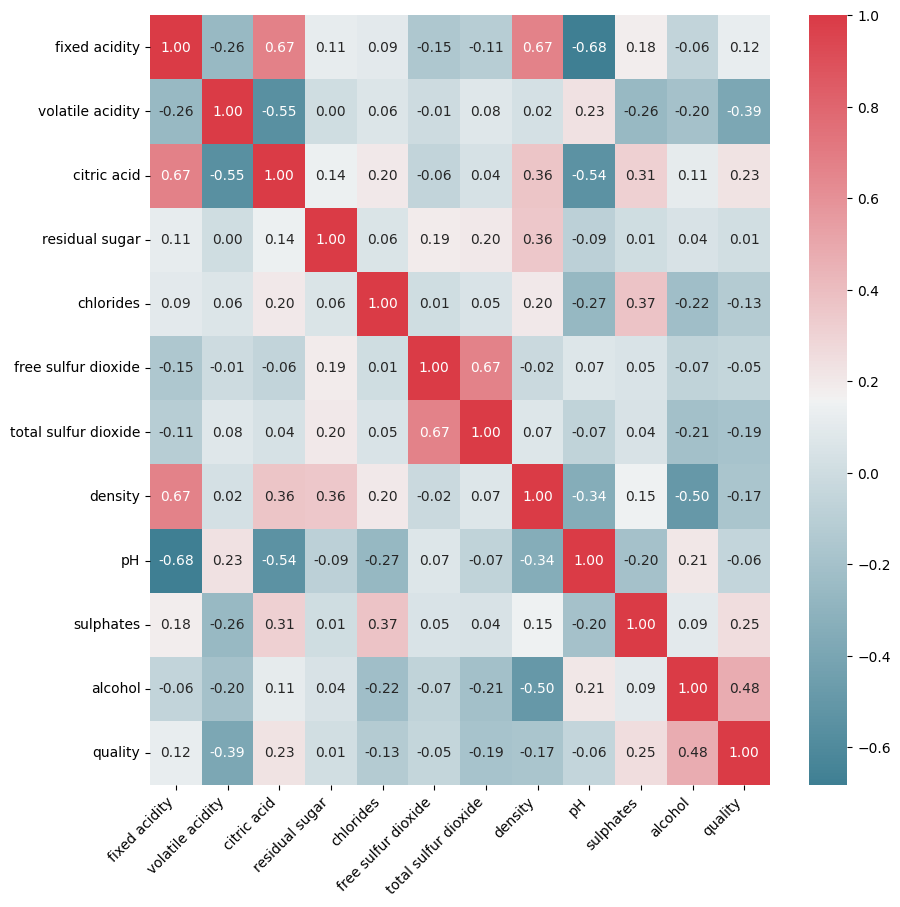

In [4]:
# Full correlation matrix

colum_names = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
# Correlation matrix
correlations = df.corr()
# Plot figsize
fig, ax = plt.subplots(figsize=(10, 10))
# Generate Color Map
colormap = sns.diverging_palette(220, 10, as_cmap=True)
# Generate Heat Map, allow annotations and place floats in map
sns.heatmap(correlations, cmap=colormap, annot=True, fmt=".2f")
ax.set_xticklabels(
    colum_names,
    rotation=45,
    horizontalalignment='right'
);
ax.set_yticklabels(colum_names);
plt.show()

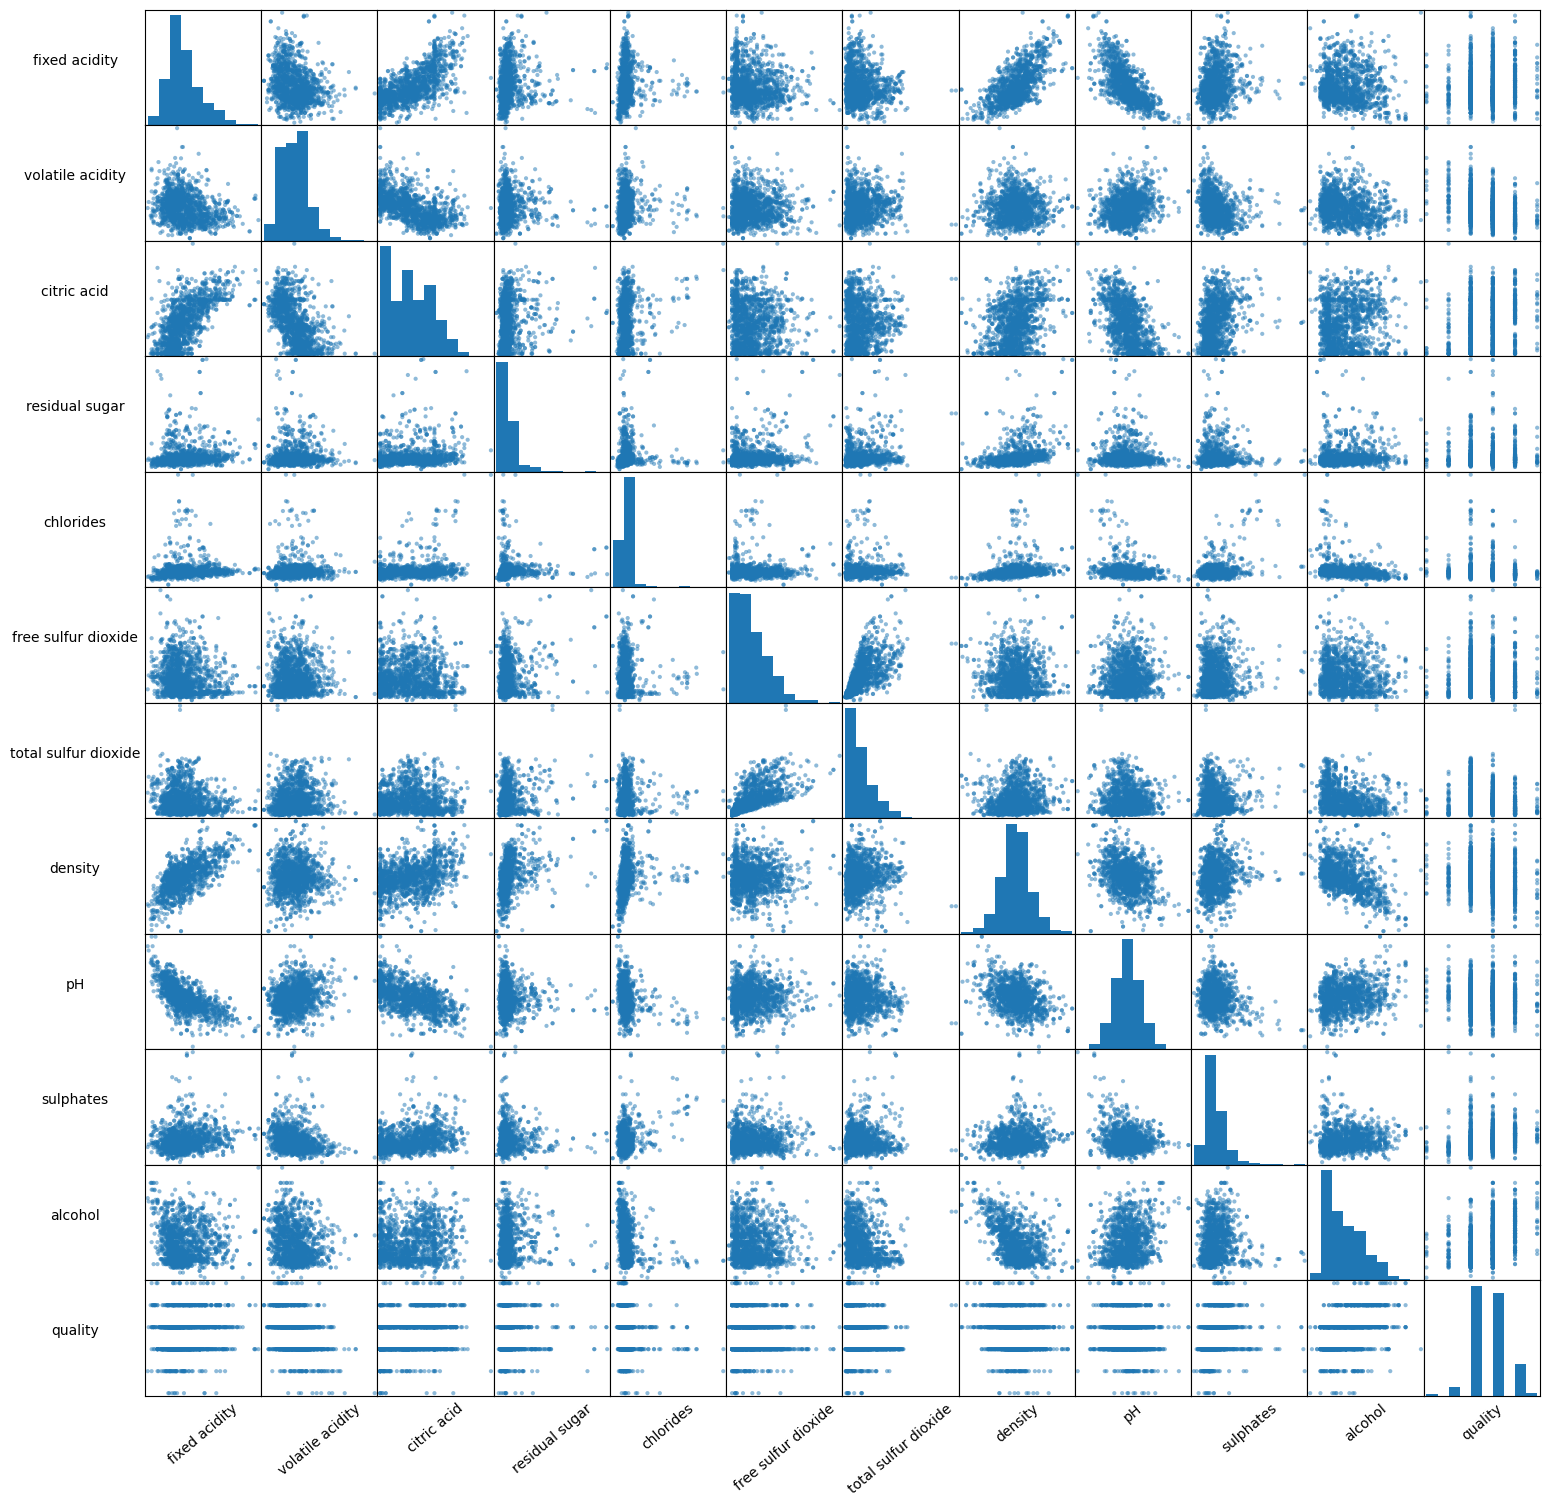

In [17]:
# Scatterplot Matrix
sm = pd.plotting.scatter_matrix(df, figsize=(18, 18), diagonal='hist')
#Change label rotation
[s.xaxis.label.set_rotation(40) for s in sm.reshape(-1)]
[s.yaxis.label.set_rotation(0) for s in sm.reshape(-1)]
#May need to offset label when rotating to prevent overlap of figure
[s.get_yaxis().set_label_coords(-0.6,0.5) for s in sm.reshape(-1)]
#Hide all ticks
[s.set_xticks(()) for s in sm.reshape(-1)]
[s.set_yticks(()) for s in sm.reshape(-1)]
plt.show()

# Note the high positive correlation e.g. between "fixed acidity" and "density" (can be read as 0.67 from the correlation matrix)

## Prepare the data for classification

223     6
1510    6
280     6
810     5
166     5
       ..
1341    6
143     5
474     6
318     7
1156    7
Name: quality, Length: 1279, dtype: int64
443     7
868     6
625     5
77      6
195     5
       ..
952     7
202     5
357     7
484     6
1425    6
Name: quality, Length: 320, dtype: int64
223     0
1510    0
280     0
810     0
166     0
       ..
1341    0
143     0
474     0
318     1
1156    1
Name: quality, Length: 1279, dtype: category
Categories (2, int64): [0 < 1]
443     1
868     0
625     0
77      0
195     0
       ..
952     1
202     0
357     1
484     0
1425    0
Name: quality, Length: 320, dtype: category
Categories (2, int64): [0 < 1]


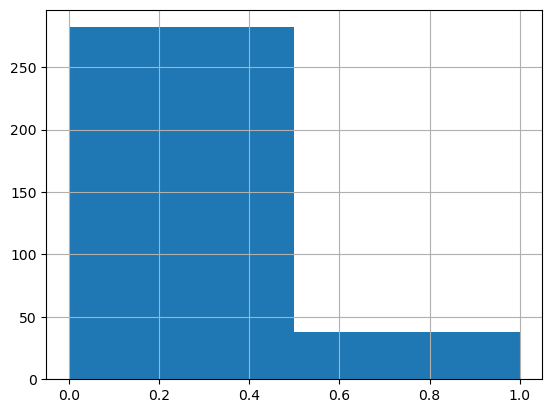

In [20]:
# Turn the problem into a binary problem - good and bad wines

print(y_train)
print(y_test)

# Dividing wine as good and bad by giving the limit for the quality
bins = (2, 6, 8) # 2-6: poor, 7-8: good
group_names = [0, 1]
y_train = pd.cut(y_train, bins = bins, labels = group_names)
y_test = pd.cut(y_test, bins = bins, labels = group_names)

#sns.countplot(y_test, native_scale=True)
#plt.show()
y_test.hist(bins=2);

print(y_train)
print(y_test)

## KNN Classification
By definition a confusion matrix $C$ is such that $C_{i, j}$ is equal to the number of observations known to be in group $i$ but predicted to be in group $j$.
Score returns the mean accuracy on the given test data and labels.
Experiment with the setting for the number of neighbours.
More information on the classifier is here: http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [22]:
knn=neighbors.KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)
knnresult=knn.predict(X_test)
print("KNN ",knn.score(X_test,y_test))
print(metrics.confusion_matrix(y_test,knnresult))

KNN  0.88125
[[257  25]
 [ 13  25]]


In [23]:
# Cross-validation
print("\nCross Validation")
print("KNN")
scores = model_selection.cross_val_score(knn, X_train, y_train, cv=5)
print(scores)
print("Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std()))


Cross Validation
KNN
[0.90234375 0.8671875  0.8671875  0.86328125 0.89411765]
Accuracy: 0.879 (+/- 0.016)


In [24]:
# Grid Search
kvals=list(range(1,100,2))
knng=model_selection.GridSearchCV(estimator=knn, param_grid=dict(n_neighbors=kvals), cv=5)
knng.fit(X_train,y_train)
print("KNN Best Score: %0.3f, Best Estimator: %f" % (knng.best_score_,knng.best_estimator_.n_neighbors))
knnresult=knng.predict(X_test)
print("KNN ",knng.score(X_test,y_test))
print(metrics.confusion_matrix(y_test,knnresult))

KNN Best Score: 0.879, Best Estimator: 1.000000
KNN  0.88125
[[257  25]
 [ 13  25]]


## Logistic Regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [31]:
lrc = linear_model.LogisticRegression()
lrc.fit(X_train,y_train)  
print(lrc.coef_)
print(lrc.intercept_)
lrcresult=lrc.predict(X_test)
print("Logistic Regression ",lrc.score(X_test,y_test))
print(metrics.confusion_matrix(y_test,lrcresult))

[[ 0.60157827 -0.5806385  -0.09303321  0.31764206 -0.39031912  0.06378238
  -0.51730726 -0.45938144  0.0132743   0.67670633  0.87066273]]
[-2.82665096]
Logistic Regression  0.86875
[[264  18]
 [ 24  14]]


## SVM Classification
### Linear SVM (optimised implementation)
Experiment with the value of the C parameter (best to vary it by factors of 10, small variations have little effect) to see the effect it has on classification. More information on this classifier is here: http://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html 

For LinearSVC, the underlying C implementation uses a random number generator to select features when fitting the model. It is thus not uncommon to have slightly different results for the same input data. If that happens, try with a smaller tol parameter (from the manual). 

In [34]:
clf=svm.LinearSVC(C=0.0001)
clf.fit(X_train,y_train)
svmresult=clf.predict(X_test)
print("Linear SVM ",clf.score(X_test,y_test))
print(metrics.confusion_matrix(y_test,svmresult))

Linear SVM  0.884375
[[263  19]
 [ 18  20]]


### Linear SVM (non-optimised implementation)
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [37]:
kernelsvm=svm.SVC(kernel='linear',C=0.0001)
kernelsvm.fit(X_train,y_train)
svmresult=kernelsvm.predict(X_test)
print("Linear SVM (non-opt) ",kernelsvm.score(X_test,y_test))
print(metrics.confusion_matrix(y_test,svmresult))

Linear SVM (non-opt)  0.88125
[[282   0]
 [ 38   0]]


### Kernel SVM
More information on this classifier is here: http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

kernel values include ‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’

In [40]:
kernelsvm=svm.SVC(kernel='rbf',C=1.3,gamma=1.3)
#kernelsvm=svm.SVC(kernel='poly',C=1,gamma='auto')
#kernelsvm=svm.SVC(kernel='sigmoid',C=1,gamma='auto')
#'auto' is 1/num_features
kernelsvm.fit(X_train,y_train)
svmresult=kernelsvm.predict(X_test)
print("Kernel SVM ",kernelsvm.score(X_test,y_test))
print(metrics.confusion_matrix(y_test,svmresult))

Kernel SVM  0.921875
[[278   4]
 [ 21  17]]


In [42]:
# Then do a search over a wide parameter space. It takes a long time.
#Cvals=np.logspace(-2,10,13)
#gammavals=np.logspace(-9,3,13)

# Now do a search around these values
Cvals=np.linspace(0.2,4,30)
gammavals=np.linspace(0.2,2,30)

kernelsvmg=model_selection.GridSearchCV(estimator=kernelsvm, param_grid=dict(C=Cvals,gamma=gammavals), cv=5)
kernelsvmg.fit(X_train,y_train)
print("Kernel SVM Best Score: %0.3f, Best Estimators: C=%0.3f, Gamma=%f" % (kernelsvmg.best_score_,kernelsvmg.best_estimator_.C,kernelsvmg.best_estimator_.gamma))
svmresult=kernelsvmg.predict(X_test)
print("Kernel SVM ",kernelsvmg.score(X_test,y_test))
print(metrics.confusion_matrix(y_test,svmresult))

Kernel SVM Best Score: 0.912, Best Estimators: C=1.772, Gamma=0.634483
Kernel SVM  0.915625
[[273   9]
 [ 18  20]]


## Decision Tree
More information on this classifier is here: http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.

In [44]:
dtree=tree.DecisionTreeClassifier(criterion='entropy')
dtree.fit(X_train,y_train)
dtreeresult=dtree.predict(X_test)
print("TREE ",dtree.score(X_test,y_test))
print(metrics.confusion_matrix(y_test,dtreeresult))

TREE  0.903125
[[264  18]
 [ 13  25]]


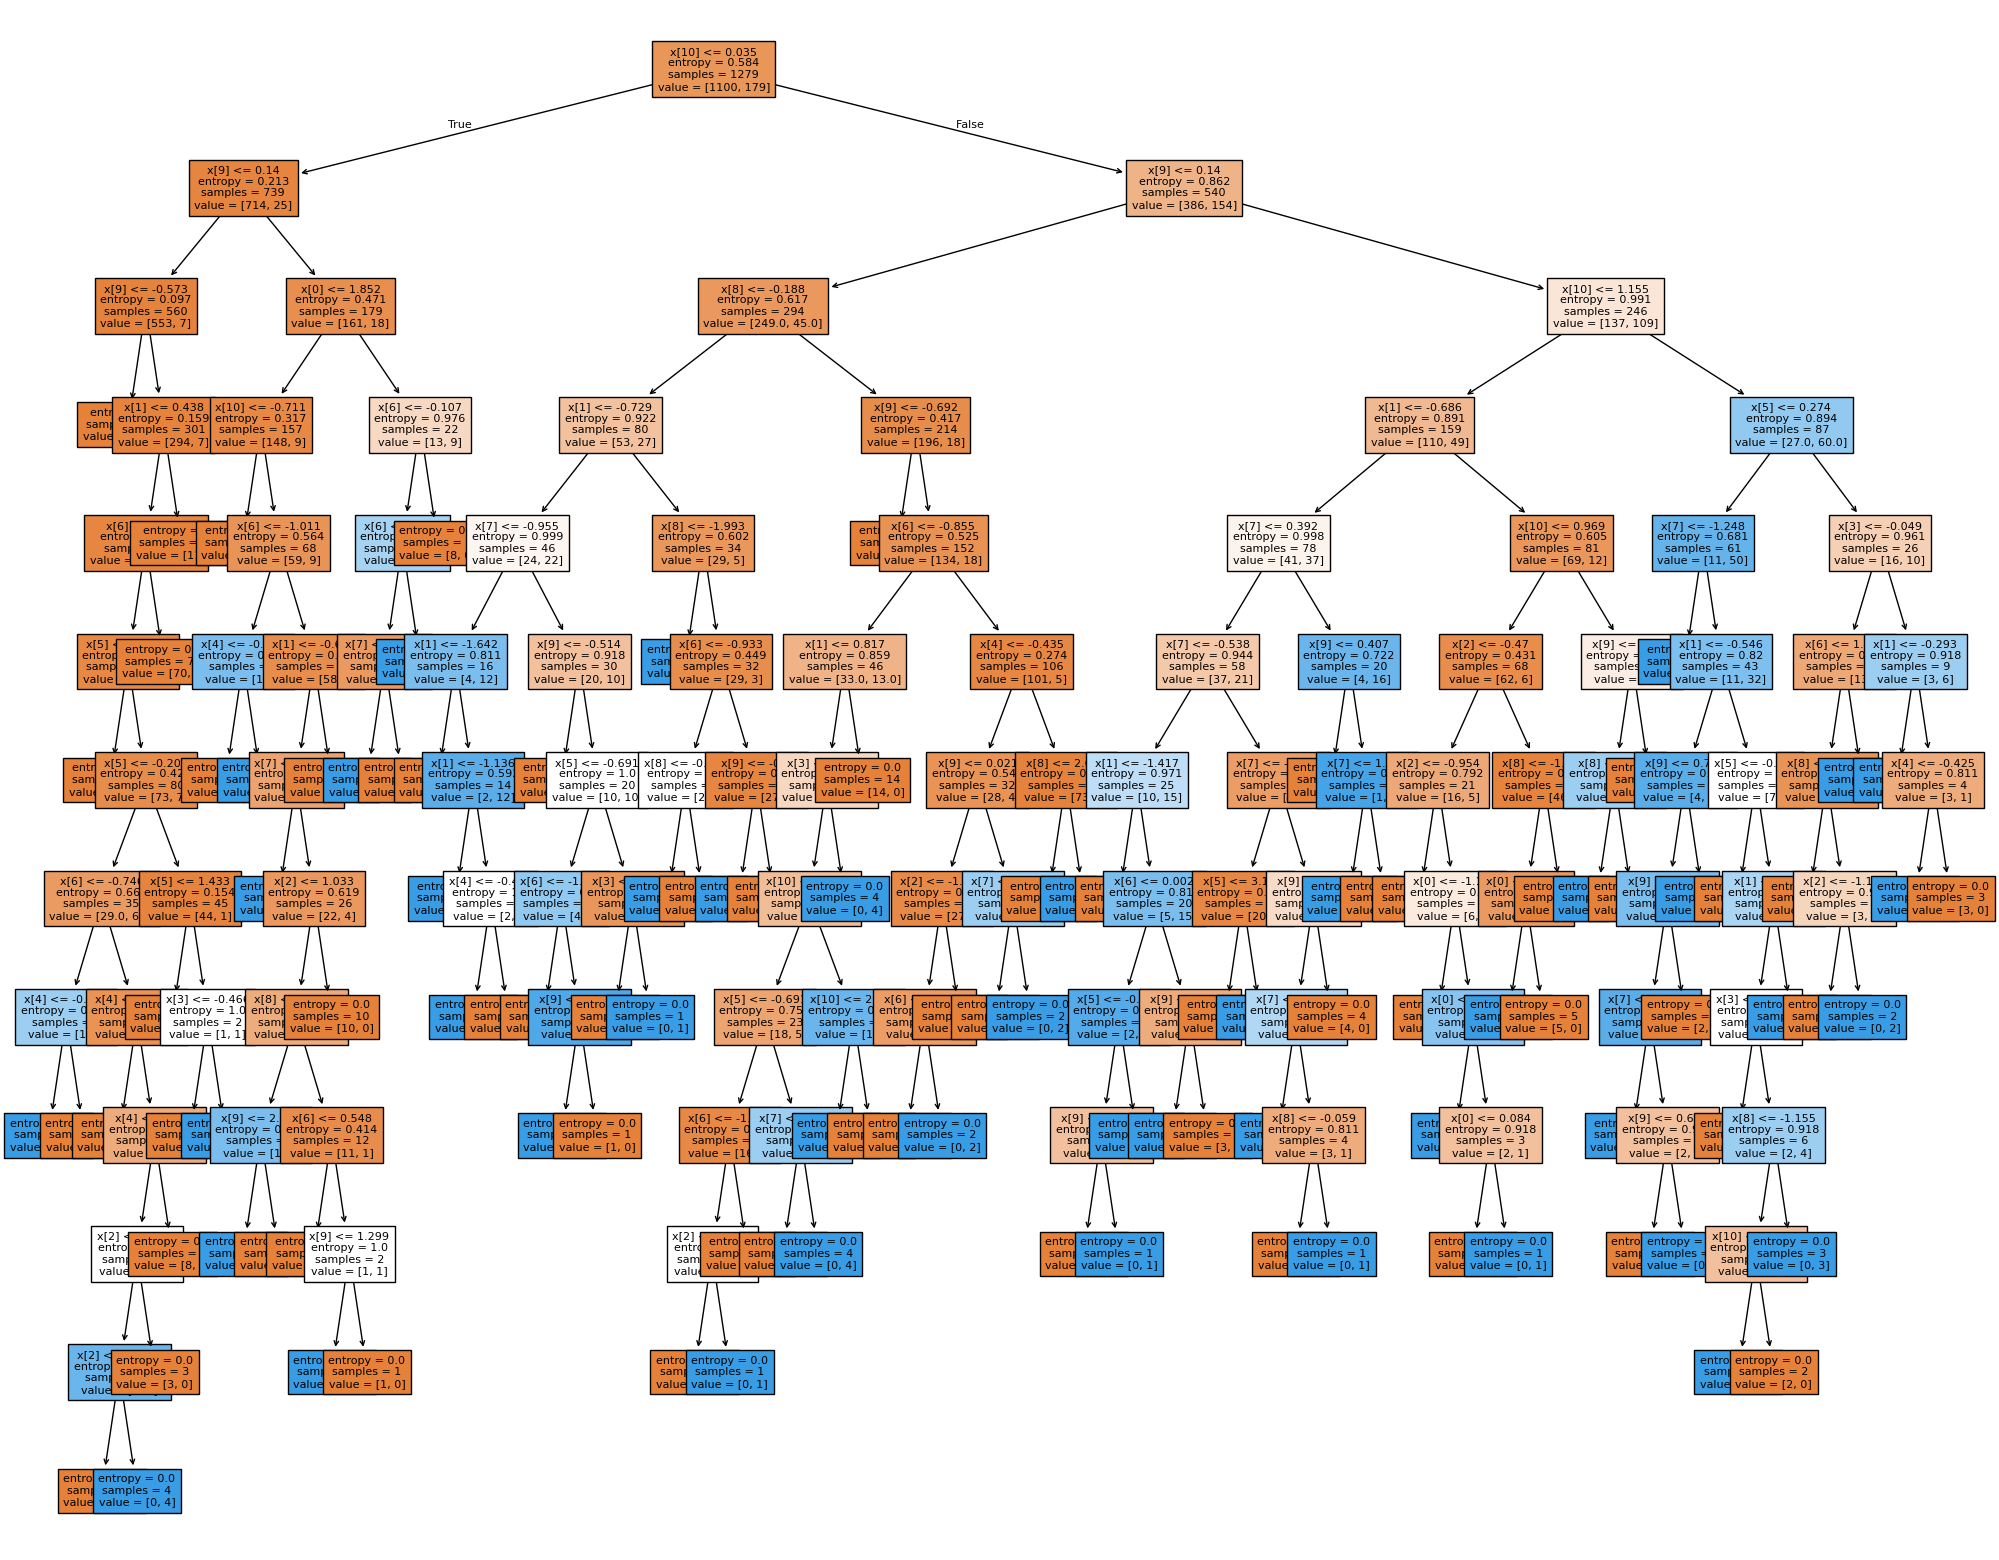

In [47]:
fig = plt.figure(figsize=(25,20))
# fontsize made larger so that upper parts of the tree are visible. Lower parts overlap.
_ = tree.plot_tree(dtree,filled=True,fontsize=8)

### Random Forest
More information on this classifier is here: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [50]:
rfc = RandomForestClassifier(n_estimators=2500,random_state=0)
rfc.fit(X_train,y_train)  
rfcresult=rfc.predict(X_test)
print("Random Forest ",rfc.score(X_test,y_test))
print(metrics.confusion_matrix(y_test,rfcresult))

Random Forest  0.91875
[[274   8]
 [ 18  20]]
